In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier # untuk perbandingan

from model.network import NeuralNetwork
from model.layers import DenseLayer
from model.activation import ActivationLayer

In [66]:
# load dataset
data = pd.read_csv('data/datasetml_2026.csv')

## 1. Exploratory Data Analysis (EDA)

### 1.1 Informasi Umum Data

In [67]:
data.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [68]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB


In [69]:
data.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [70]:
# Cek missing values
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [71]:
# Distribusi kelas target
print(data['placement_status'].value_counts())
print(data['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


### 1.2 Visualisasi Data

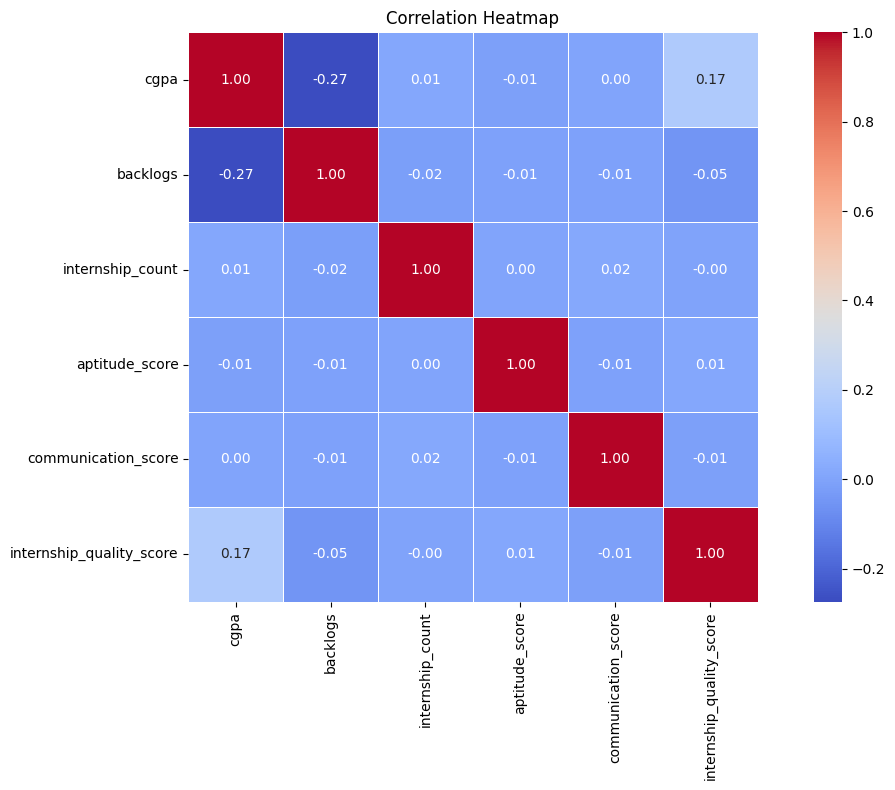

In [72]:
# Snippet: heatmap korelasi fitur numerik
# -------------------------------------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()


plt.figure(figsize=(12, 8))
corr_matrix = data[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

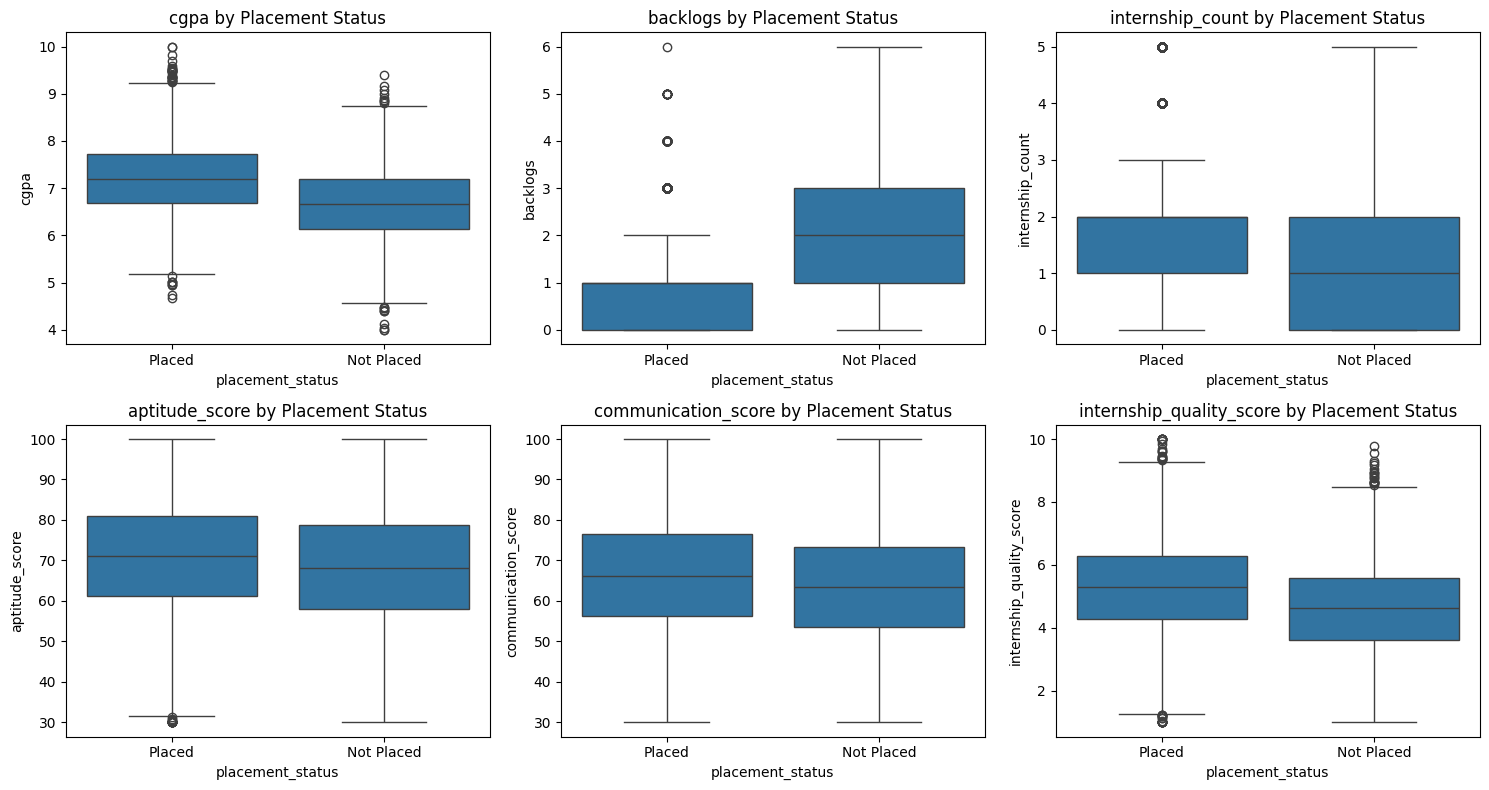

In [73]:
# Snippet: boxplot untuk deteksi outlier per kelas target
# -------------------------------------------------------
num_features = [col for col in num_cols if col != 'placement_status']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_features):
    sns.boxplot(data=data, x='placement_status', y=col, ax=ax)
    ax.set_title(f'{col} by Placement Status')

plt.tight_layout()
plt.show()

### 2. Data Cleaning dan Preprocessing

In [74]:
# Salin data
data_copy = data.copy()

In [75]:
TARGET_COL = 'placement_status'

CAT_COLS = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry', 'placement_status']
NUM_COLS = [c for c in data_copy.columns if c not in CAT_COLS + [TARGET_COL]]

print("Categorical Columns:", CAT_COLS)
print("Numerical Columns:", NUM_COLS)

Categorical Columns: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry', 'placement_status']
Numerical Columns: ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


In [76]:
# Handling missing values
# Snippet: SimpleImputer
# -------------------------------------------------------
from sklearn.impute import SimpleImputer


num_imputer = SimpleImputer(strategy='median')  
data_copy[NUM_COLS] = num_imputer.fit_transform(data_copy[NUM_COLS])

cat_imputer = SimpleImputer(strategy='most_frequent')
data_copy[CAT_COLS] = cat_imputer.fit_transform(data_copy[CAT_COLS])


In [77]:
# Handling outlier
# Snippet: Deteksi outlier dengan IQR
# -------------------------------------------------------
def get_iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in NUM_COLS:
    lower, upper = get_iqr_bounds(data_copy[col])
    data_copy[col] = data_copy[col].clip(lower, upper)
    n = ((data_copy[col] < lower) | (data_copy[col] > upper)).sum()


    print(f"{col}: {n} outliers")

cgpa: 0 outliers
backlogs: 0 outliers
internship_count: 0 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 0 outliers


In [78]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# Fit hanya di data_copying
encoder.fit(data_copy[CAT_COLS])

# Transform keduanya
data_copy_encoded = encoder.transform(data_copy[CAT_COLS])

data_copy_encoded = pd.DataFrame(
    data_copy_encoded,
    columns=encoder.get_feature_names_out(CAT_COLS),
)


data_copy = pd.concat(
    [data_copy.drop(columns=CAT_COLS), data_copy_encoded],
    axis=1
)


In [79]:
data_copy.head()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score,college_tier_Tier 2,college_tier_Tier 3,country_Germany,country_India,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech,placement_status_Placed
0,7.397371,1.0,2.0,53.574150,64.177062,5.481450,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6.889389,0.0,1.0,60.687750,88.346052,4.625099,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,7.518151,0.0,2.0,64.568750,69.493171,5.227939,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,8.218424,0.0,3.0,73.461500,78.204854,5.150674,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6.812677,1.0,3.5,86.518121,44.680881,3.888824,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [80]:
from sklearn.model_selection import train_test_split


feature_cols = [c for c in data_copy.columns if c not in [TARGET_COL]]

X = data_copy[feature_cols]
y = data_copy['placement_status_Placed']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,        
    random_state=42,
    stratify=y          
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)

X_train: (8000, 24) | y_train: (8000,)
X_val:   (2000, 24) | y_val:   (2000,)


In [81]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy().reshape(-1, 1)

X_val_np = X_val.to_numpy()
y_val_np = y_val.to_numpy().reshape(-1, 1)

### 3. Modeling and Validation

In [82]:
# Helper: evaluasi model dan simpan hasil
from sklearn.metrics import f1_score


results = {}

def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred = model.predict(X_val)
    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_val, y_pred,
                                target_names=['Rejected (0)', 'Approved (1)']))
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
    return macro_f1

## Pengujian

### Pengujian 1. Hyperparameter

### Pengujian 1.1. Pengaruh depth dan width

### Width berbeda

In [83]:
#  init import class 

from model.functions import ActivationFunctions, LossFunctions
from model.initializers import Initializers

activation_fn = ActivationFunctions()
loss_fn = LossFunctions()
init_fn = Initializers()

relu = activation_fn.relu
relu_prime = activation_fn.relu_prime
sigmoid = activation_fn.sigmoid
sigmoid_prime = activation_fn.sigmoid_prime
linear = activation_fn.linear
linear_prime = activation_fn.linear_prime
softmax = activation_fn.softmax
softmax_prime = activation_fn.softmax_prime
hyperbolic_tangent = activation_fn.hyperbolic_tangent
hyperbolic_tangent_prime = activation_fn.hyperbolic_tangent_prime

mse = loss_fn.mse
mse_prime = loss_fn.mse_prime

he_init = init_fn.he_init
uniform_init = init_fn.uniform_init
xavier_init = init_fn.xavier_init

Epoch 1/10, Train Loss=0.318770, Val Loss=0.317478
Epoch 2/10, Train Loss=0.316205, Val Loss=0.314935
Epoch 3/10, Train Loss=0.313686, Val Loss=0.312440
Epoch 4/10, Train Loss=0.311217, Val Loss=0.309995
Epoch 5/10, Train Loss=0.308798, Val Loss=0.307600
Epoch 6/10, Train Loss=0.306430, Val Loss=0.305257
Epoch 7/10, Train Loss=0.304114, Val Loss=0.302966
Epoch 8/10, Train Loss=0.301850, Val Loss=0.300728
Epoch 9/10, Train Loss=0.299640, Val Loss=0.298543
Epoch 10/10, Train Loss=0.297483, Val Loss=0.296412


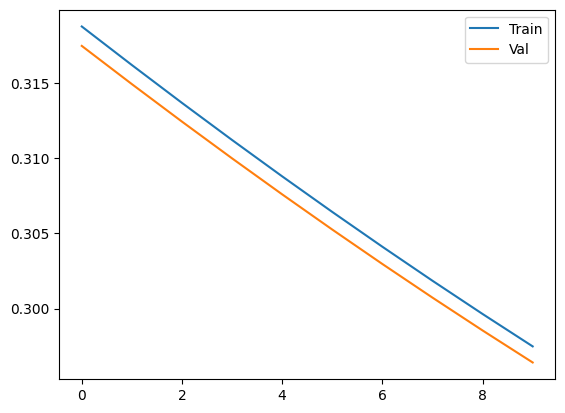

In [84]:

model = NeuralNetwork()
model.add(DenseLayer(24, 8, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(relu, relu_prime))
model.add(DenseLayer(8, 8, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(sigmoid, sigmoid_prime))
model.add(DenseLayer(8, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(sigmoid, sigmoid_prime))

model.use(mse, mse_prime)

history = model.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=10,
    batch_size=32,
    learning_rate=0.01,
    verbose=1  # Shows progress
)

# Plot results
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.legend()
plt.show()

Epoch 1/10, Train Loss=0.286573, Val Loss=0.262331
Epoch 2/10, Train Loss=0.253637, Val Loss=0.247287
Epoch 3/10, Train Loss=0.245530, Val Loss=0.242834
Epoch 4/10, Train Loss=0.242493, Val Loss=0.240955
Epoch 5/10, Train Loss=0.240905, Val Loss=0.239809
Epoch 6/10, Train Loss=0.239876, Val Loss=0.239031
Epoch 7/10, Train Loss=0.239159, Val Loss=0.238472
Epoch 8/10, Train Loss=0.238637, Val Loss=0.238071
Epoch 9/10, Train Loss=0.238247, Val Loss=0.237766
Epoch 10/10, Train Loss=0.237946, Val Loss=0.237535


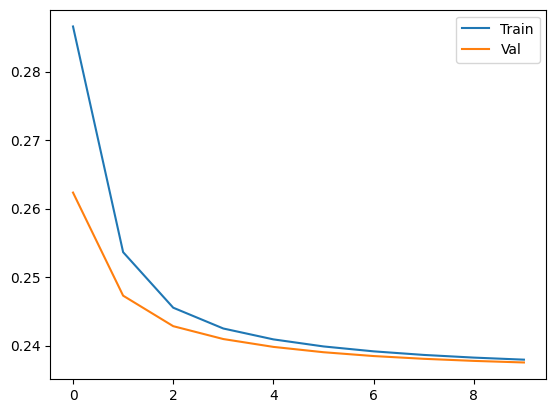

In [85]:
model = NeuralNetwork()
model.add(DenseLayer(24, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(relu, relu_prime))
model.add(DenseLayer(16, 8, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(sigmoid, sigmoid_prime))
model.add(DenseLayer(8, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(sigmoid, sigmoid_prime))

model.use(mse, mse_prime)

history = model.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=10,
    batch_size=32,
    learning_rate=0.01,
    verbose=1  # Shows progress
)

# Plot results
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.legend()
plt.show()

Epoch 1/10, Train Loss=0.291363, Val Loss=0.253512
Epoch 2/10, Train Loss=0.250932, Val Loss=0.248011
Epoch 3/10, Train Loss=0.247526, Val Loss=0.245985
Epoch 4/10, Train Loss=0.245778, Val Loss=0.244619
Epoch 5/10, Train Loss=0.244494, Val Loss=0.243527
Epoch 6/10, Train Loss=0.243442, Val Loss=0.242603
Epoch 7/10, Train Loss=0.242545, Val Loss=0.241800
Epoch 8/10, Train Loss=0.241763, Val Loss=0.241090
Epoch 9/10, Train Loss=0.241072, Val Loss=0.240457
Epoch 10/10, Train Loss=0.240456, Val Loss=0.239891


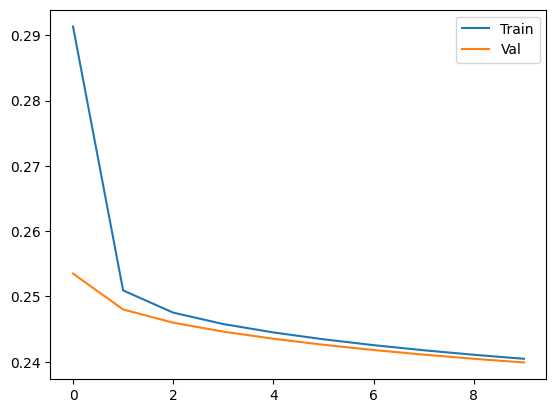

In [86]:
model = NeuralNetwork()
model.add(DenseLayer(24, 32, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(relu, relu_prime))
model.add(DenseLayer(32, 8, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(sigmoid, sigmoid_prime))
model.add(DenseLayer(8, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(sigmoid, sigmoid_prime))

model.use(mse, mse_prime)

history = model.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=10,
    batch_size=32,
    learning_rate=0.01,
    verbose=1  # Shows progress
)

# Plot results
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.legend()
plt.show()

### Depth berbeda

Epoch 1/10, Train Loss=0.384750, Val Loss=0.384500
Epoch 2/10, Train Loss=0.384750, Val Loss=0.384500
Epoch 3/10, Train Loss=0.384750, Val Loss=0.384500
Epoch 4/10, Train Loss=0.384750, Val Loss=0.384500
Epoch 5/10, Train Loss=0.384750, Val Loss=0.384500
Epoch 6/10, Train Loss=0.384750, Val Loss=0.384500
Epoch 7/10, Train Loss=0.384750, Val Loss=0.384500
Epoch 8/10, Train Loss=0.384750, Val Loss=0.384500
Epoch 9/10, Train Loss=0.384750, Val Loss=0.384500
Epoch 10/10, Train Loss=0.384750, Val Loss=0.384500


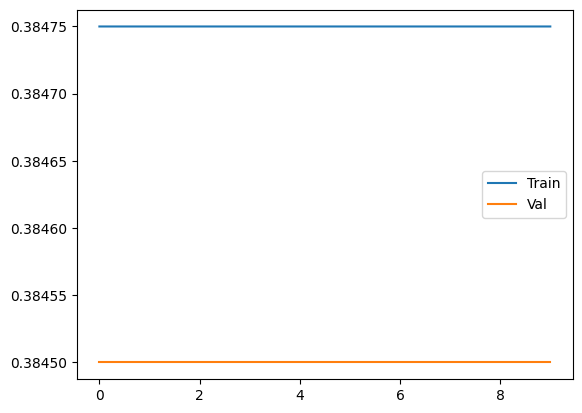

In [87]:
model = NeuralNetwork()
model.add(DenseLayer(24, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(relu, relu_prime))
model.add(DenseLayer(16, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(sigmoid, sigmoid_prime))


model.use(mse, mse_prime)

history = model.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=10,
    batch_size=32,
    learning_rate=0.01,
    verbose=1  # Shows progress
)

# Plot results
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.legend()
plt.show()

Epoch 1/10, Train Loss=0.384271, Val Loss=0.383716
Epoch 2/10, Train Loss=0.383705, Val Loss=0.382212
Epoch 3/10, Train Loss=0.356830, Val Loss=0.329672
Epoch 4/10, Train Loss=0.319209, Val Loss=0.327061
Epoch 5/10, Train Loss=0.311086, Val Loss=0.316251
Epoch 6/10, Train Loss=0.306967, Val Loss=0.312256
Epoch 7/10, Train Loss=0.304003, Val Loss=0.306972
Epoch 8/10, Train Loss=0.299448, Val Loss=0.303623
Epoch 9/10, Train Loss=0.296125, Val Loss=0.298238
Epoch 10/10, Train Loss=0.291714, Val Loss=0.296177


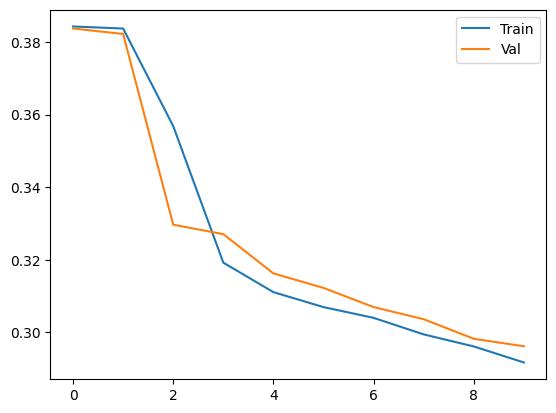

In [88]:
model = NeuralNetwork()
model.add(DenseLayer(24, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(relu, relu_prime))
model.add(DenseLayer(16, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(relu, relu_prime))
model.add(DenseLayer(16, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(sigmoid, sigmoid_prime))


model.use(mse, mse_prime)

history = model.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=10,
    batch_size=32,
    learning_rate=0.01,
    verbose=1  # Shows progress
)

# Plot results
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.legend()
plt.show()

Epoch 1/10, Train Loss=0.615250, Val Loss=0.615500
Epoch 2/10, Train Loss=0.615250, Val Loss=0.615500
Epoch 3/10, Train Loss=0.615250, Val Loss=0.615500
Epoch 4/10, Train Loss=0.615250, Val Loss=0.615500
Epoch 5/10, Train Loss=0.615250, Val Loss=0.615500
Epoch 6/10, Train Loss=0.615250, Val Loss=0.615500
Epoch 7/10, Train Loss=0.615250, Val Loss=0.615500
Epoch 8/10, Train Loss=0.615250, Val Loss=0.615500
Epoch 9/10, Train Loss=0.615250, Val Loss=0.615500
Epoch 10/10, Train Loss=0.615250, Val Loss=0.615500


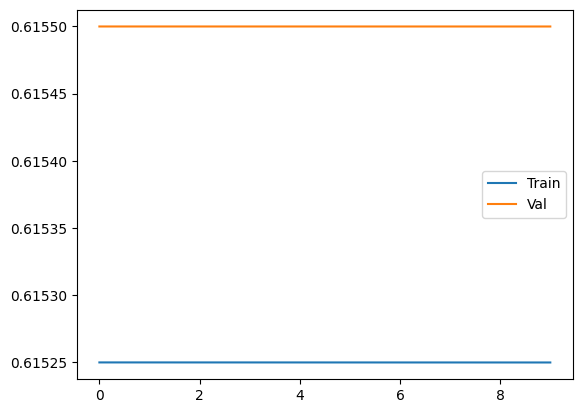

In [89]:
model = NeuralNetwork()
model.add(DenseLayer(24, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(relu, relu_prime))
model.add(DenseLayer(16, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(relu, relu_prime))
model.add(DenseLayer(16, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(relu, relu_prime))
model.add(DenseLayer(16, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
model.add(ActivationLayer(sigmoid, sigmoid_prime))


model.use(mse, mse_prime)

history = model.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=10,
    batch_size=32,
    learning_rate=0.01,
    verbose=1  # Shows progress
)

# Plot results
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.legend()
plt.show()

### Pengujian 1.2. Activation Function

In [90]:
activation = {
    "linear": (linear, linear_prime),
    "relu": (relu, relu_prime),
    "sigmoid": (sigmoid, sigmoid_prime),
    "tanh": (hyperbolic_tangent, hyperbolic_tangent_prime),
    # "softmax": (softmax, softmax_prime)
}



for act in activation:
    print(f"Testing activation function: {act}")
    model = NeuralNetwork()
    model.add(DenseLayer(24, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(*activation[act]))
    model.add(DenseLayer(16, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(*activation[act]))
    model.add(DenseLayer(16, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(softmax, softmax_prime))

    model.use(mse, mse_prime)

    history = model.train(
        X_train_np, y_train_np,
        X_val_np, y_val_np,
        epochs=10,
        batch_size=32,
        learning_rate=0.01,
        verbose=1
    )

    plt.title(f"Activation Function: {act}")
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.legend()
    plt.show()


Testing activation function: linear


ValueError: shapes (32,32) and (1,16) not aligned: 32 (dim 1) != 1 (dim 0)

### Pengujian 1.3. Learning Rate

Testing learning rate: learning rate 0.0001
Epoch 1/10, Train Loss=0.384376, Val Loss=0.384031
Epoch 2/10, Train Loss=0.384374, Val Loss=0.384029
Epoch 3/10, Train Loss=0.384373, Val Loss=0.384027
Epoch 4/10, Train Loss=0.384371, Val Loss=0.384025
Epoch 5/10, Train Loss=0.384369, Val Loss=0.384023
Epoch 6/10, Train Loss=0.384368, Val Loss=0.384021
Epoch 7/10, Train Loss=0.384366, Val Loss=0.384019
Epoch 8/10, Train Loss=0.384365, Val Loss=0.384017
Epoch 9/10, Train Loss=0.384363, Val Loss=0.384015
Epoch 10/10, Train Loss=0.384361, Val Loss=0.384013


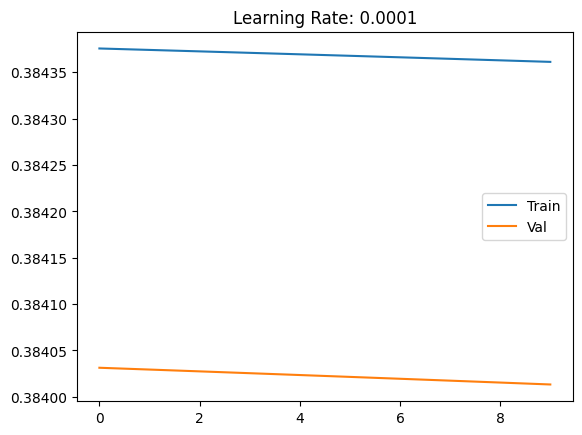

Testing learning rate: learning rate 0.001
Epoch 1/10, Train Loss=0.384369, Val Loss=0.384013
Epoch 2/10, Train Loss=0.384352, Val Loss=0.383992
Epoch 3/10, Train Loss=0.384334, Val Loss=0.383968
Epoch 4/10, Train Loss=0.384314, Val Loss=0.383942
Epoch 5/10, Train Loss=0.384292, Val Loss=0.383914
Epoch 6/10, Train Loss=0.384268, Val Loss=0.383882
Epoch 7/10, Train Loss=0.384241, Val Loss=0.383847
Epoch 8/10, Train Loss=0.384211, Val Loss=0.383808
Epoch 9/10, Train Loss=0.384177, Val Loss=0.383764
Epoch 10/10, Train Loss=0.384139, Val Loss=0.383714


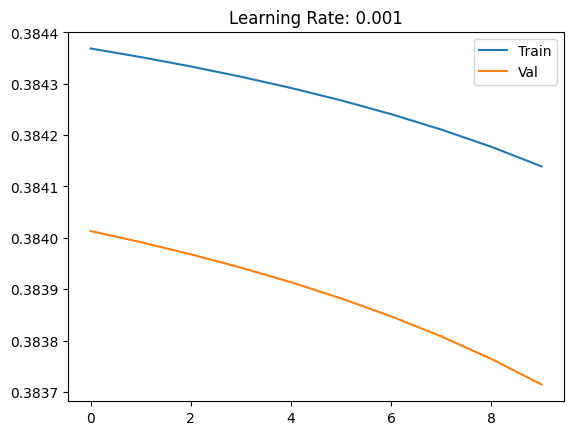

Testing learning rate: learning rate 0.01
Epoch 1/10, Train Loss=0.384271, Val Loss=0.383716
Epoch 2/10, Train Loss=0.383705, Val Loss=0.382212
Epoch 3/10, Train Loss=0.356830, Val Loss=0.329672
Epoch 4/10, Train Loss=0.319209, Val Loss=0.327061
Epoch 5/10, Train Loss=0.311086, Val Loss=0.316251
Epoch 6/10, Train Loss=0.306967, Val Loss=0.312256
Epoch 7/10, Train Loss=0.304003, Val Loss=0.306972
Epoch 8/10, Train Loss=0.299448, Val Loss=0.303623
Epoch 9/10, Train Loss=0.296125, Val Loss=0.298238
Epoch 10/10, Train Loss=0.291714, Val Loss=0.296177


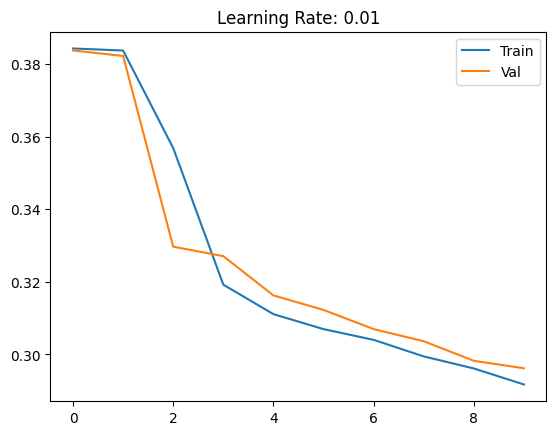

Testing learning rate: learning rate 0.1
Epoch 1/10, Train Loss=0.371288, Val Loss=0.378326
Epoch 2/10, Train Loss=0.360352, Val Loss=0.376474
Epoch 3/10, Train Loss=0.349699, Val Loss=0.302575
Epoch 4/10, Train Loss=0.322074, Val Loss=0.299918
Epoch 5/10, Train Loss=0.286873, Val Loss=0.263330
Epoch 6/10, Train Loss=0.266496, Val Loss=0.236196
Epoch 7/10, Train Loss=0.248826, Val Loss=0.227555
Epoch 8/10, Train Loss=0.237661, Val Loss=0.227915
Epoch 9/10, Train Loss=0.232033, Val Loss=0.212308
Epoch 10/10, Train Loss=0.220439, Val Loss=0.205737


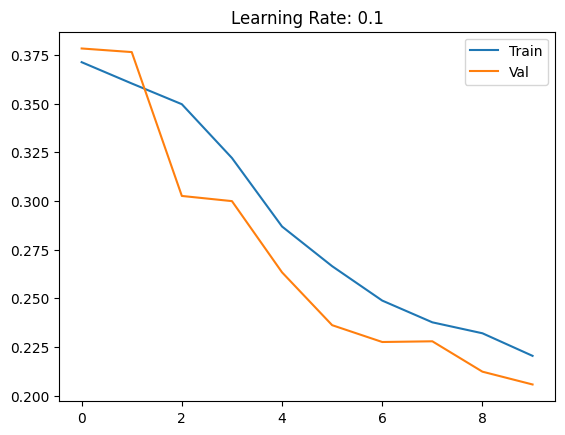

In [91]:
learning_rate = {
    "learning rate 0.0001": 0.0001,
    "learning rate 0.001": 0.001,
    "learning rate 0.01": 0.01,
    "learning rate 0.1": 0.1
}

for lr in learning_rate:
    print(f"Testing learning rate: {lr}")
    model = NeuralNetwork()
    model.add(DenseLayer(24, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    model.add(DenseLayer(16, 16, he_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(relu, relu_prime))
    model.add(DenseLayer(16, 1, xavier_init, l1_lambda=0.001, l2_lambda=0.01, seed=42))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))  # output layer sigmoid

    model.use(mse, mse_prime)

    history = model.train(
        X_train_np, y_train_np,
        X_val_np, y_val_np,
        epochs=10,
        batch_size=32,
        learning_rate=learning_rate[lr],
        verbose=1
    )

    plt.title(f"Learning Rate: {learning_rate[lr]}")
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.legend()
    plt.show()


### Test Regularization

In [92]:
# init
bce = loss_fn.binary_cross_entropy
bce_prime = loss_fn.bce_prime

# helper build model
def build_regularization_model(l1_lambda=0.0, l2_lambda=0.0, seed=42):
    model = NeuralNetwork()

    model.add(DenseLayer(24, 16, he_init, l1_lambda=l1_lambda, l2_lambda=l2_lambda, seed=seed))
    model.add(ActivationLayer(relu, relu_prime))

    model.add(DenseLayer(16, 8, xavier_init, l1_lambda=l1_lambda, l2_lambda=l2_lambda, seed=seed))
    model.add(ActivationLayer(relu, relu_prime))

    model.add(DenseLayer(8, 1, xavier_init, l1_lambda=l1_lambda, l2_lambda=l2_lambda, seed=seed))
    model.add(ActivationLayer(sigmoid, sigmoid_prime))

    model.use(bce, bce_prime)
    return model

# helper evaluasi prediksi
def evaluate_binary_model(model, X_val, y_val, model_name="Model", threshold=0.5):
    y_prob = model.predict(X_val)
    y_pred = (y_prob >= threshold).astype(int).reshape(-1)
    y_true = y_val.reshape(-1)

    print()
    print(model_name)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Not Placed", "Placed"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()
    accuracy = report_df.loc["accuracy", "precision"]
    report_df = report_df.drop("accuracy")
    display(report_df)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Accuracy  : {acc:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")
    print()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [94]:
# init hyperparameter untuk regularization
EPOCHS = 20
BATCH_SIZE = 32
LEARNING_RATE = 0.01
REG_LAMBDA = 0.001
SEED = 42

#### a. Tanpa regularisasi

In [95]:
model_none = build_regularization_model(l1_lambda=0.0, l2_lambda=0.0, seed=SEED)

history_none = model_none.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

result_none = evaluate_binary_model(model_none, X_val_np, y_val_np, "No Regularization")

Epoch 1/20, Train Loss=0.950784, Val Loss=0.869382
Epoch 2/20, Train Loss=0.736418, Val Loss=1.085613
Epoch 3/20, Train Loss=0.680811, Val Loss=0.650938
Epoch 4/20, Train Loss=0.652028, Val Loss=0.626295
Epoch 5/20, Train Loss=0.635281, Val Loss=0.690886
Epoch 6/20, Train Loss=0.628828, Val Loss=0.587702
Epoch 7/20, Train Loss=0.608697, Val Loss=0.550419
Epoch 8/20, Train Loss=0.585676, Val Loss=0.571967
Epoch 9/20, Train Loss=0.585440, Val Loss=0.527662
Epoch 10/20, Train Loss=0.566265, Val Loss=0.525791
Epoch 11/20, Train Loss=0.557362, Val Loss=0.562726
Epoch 12/20, Train Loss=0.552809, Val Loss=0.541892
Epoch 13/20, Train Loss=0.544884, Val Loss=0.504189
Epoch 14/20, Train Loss=0.546066, Val Loss=0.572486
Epoch 15/20, Train Loss=0.520792, Val Loss=0.480867
Epoch 16/20, Train Loss=0.521344, Val Loss=0.485824
Epoch 17/20, Train Loss=0.514306, Val Loss=0.465534
Epoch 18/20, Train Loss=0.499560, Val Loss=0.460617
Epoch 19/20, Train Loss=0.496685, Val Loss=0.456933
Epoch 20/20, Train Lo

,precision,recall,f1-score,support
Not Placed,0.724971,0.819246,0.769231,769.0
Placed,0.877100,0.805849,0.839966,1231.0
macro avg,0.801036,0.812547,0.804598,2000.0
weighted avg,0.818606,0.811000,0.812768,2000.0


Accuracy  : 0.8110
Macro F1  : 0.8046



#### b. L1 Regularization

In [96]:
model_l1 = build_regularization_model(l1_lambda=REG_LAMBDA, l2_lambda=0.0, seed=SEED)

history_l1 = model_l1.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

result_l1 = evaluate_binary_model(model_l1, X_val_np, y_val_np, "L1 Regularization")

Epoch 1/20, Train Loss=0.950687, Val Loss=0.868989
Epoch 2/20, Train Loss=0.736135, Val Loss=1.083601
Epoch 3/20, Train Loss=0.680488, Val Loss=0.651035
Epoch 4/20, Train Loss=0.651714, Val Loss=0.625746
Epoch 5/20, Train Loss=0.634905, Val Loss=0.689774
Epoch 6/20, Train Loss=0.628339, Val Loss=0.587941
Epoch 7/20, Train Loss=0.608283, Val Loss=0.550768
Epoch 8/20, Train Loss=0.585385, Val Loss=0.571416
Epoch 9/20, Train Loss=0.585048, Val Loss=0.528021
Epoch 10/20, Train Loss=0.565997, Val Loss=0.526124
Epoch 11/20, Train Loss=0.557161, Val Loss=0.562547
Epoch 12/20, Train Loss=0.552469, Val Loss=0.542371
Epoch 13/20, Train Loss=0.544590, Val Loss=0.504557
Epoch 14/20, Train Loss=0.545530, Val Loss=0.571870
Epoch 15/20, Train Loss=0.520639, Val Loss=0.481850
Epoch 16/20, Train Loss=0.521080, Val Loss=0.486650
Epoch 17/20, Train Loss=0.514126, Val Loss=0.466334
Epoch 18/20, Train Loss=0.499519, Val Loss=0.461171
Epoch 19/20, Train Loss=0.496564, Val Loss=0.457869
Epoch 20/20, Train Lo

,precision,recall,f1-score,support
Not Placed,0.723624,0.820546,0.769043,769.0
Placed,0.877660,0.804224,0.839339,1231.0
macro avg,0.800642,0.812385,0.804191,2000.0
weighted avg,0.818433,0.810500,0.812310,2000.0


Accuracy  : 0.8105
Macro F1  : 0.8042



#### c. L2 Regularization

In [97]:
model_l2 = build_regularization_model(l1_lambda=0.0, l2_lambda=REG_LAMBDA, seed=SEED)

history_l2 = model_l2.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

result_l2 = evaluate_binary_model(model_l2, X_val_np, y_val_np, "L2 Regularization")

Epoch 1/20, Train Loss=0.950750, Val Loss=0.869219
Epoch 2/20, Train Loss=0.736307, Val Loss=1.084665
Epoch 3/20, Train Loss=0.680651, Val Loss=0.650937
Epoch 4/20, Train Loss=0.651848, Val Loss=0.626055
Epoch 5/20, Train Loss=0.635109, Val Loss=0.690416
Epoch 6/20, Train Loss=0.628627, Val Loss=0.587856
Epoch 7/20, Train Loss=0.608536, Val Loss=0.550618
Epoch 8/20, Train Loss=0.585524, Val Loss=0.571015
Epoch 9/20, Train Loss=0.585287, Val Loss=0.527824
Epoch 10/20, Train Loss=0.566169, Val Loss=0.525941
Epoch 11/20, Train Loss=0.557292, Val Loss=0.562718
Epoch 12/20, Train Loss=0.552695, Val Loss=0.542142
Epoch 13/20, Train Loss=0.544763, Val Loss=0.504431
Epoch 14/20, Train Loss=0.545862, Val Loss=0.572266
Epoch 15/20, Train Loss=0.520766, Val Loss=0.481341
Epoch 16/20, Train Loss=0.521263, Val Loss=0.486257
Epoch 17/20, Train Loss=0.514282, Val Loss=0.465945
Epoch 18/20, Train Loss=0.499565, Val Loss=0.460929
Epoch 19/20, Train Loss=0.496691, Val Loss=0.457407
Epoch 20/20, Train Lo

,precision,recall,f1-score,support
Not Placed,0.724138,0.819246,0.768761,769.0
Placed,0.876991,0.805037,0.839475,1231.0
macro avg,0.800565,0.812141,0.804118,2000.0
weighted avg,0.818219,0.810500,0.812286,2000.0


Accuracy  : 0.8105
Macro F1  : 0.8041



#### Perbandingan Regularisasi

In [98]:
# tabel perbandingan
comparison_df = pd.DataFrame([
    {
        "Model": "No Regularization",
        "Accuracy": result_none["accuracy"],
        "Macro F1": result_none["macro_f1"]
    },
    {
        "Model": "L1 Regularization",
        "Accuracy": result_l1["accuracy"],
        "Macro F1": result_l1["macro_f1"]
    },
    {
        "Model": "L2 Regularization",
        "Accuracy": result_l2["accuracy"],
        "Macro F1": result_l2["macro_f1"]
    }
])

comparison_df.sort_values(by="Macro F1", ascending=False)

,Model,Accuracy,Macro F1
0,No Regularization,0.8110,0.804598
1,L1 Regularization,0.8105,0.804191
2,L2 Regularization,0.8105,0.804118


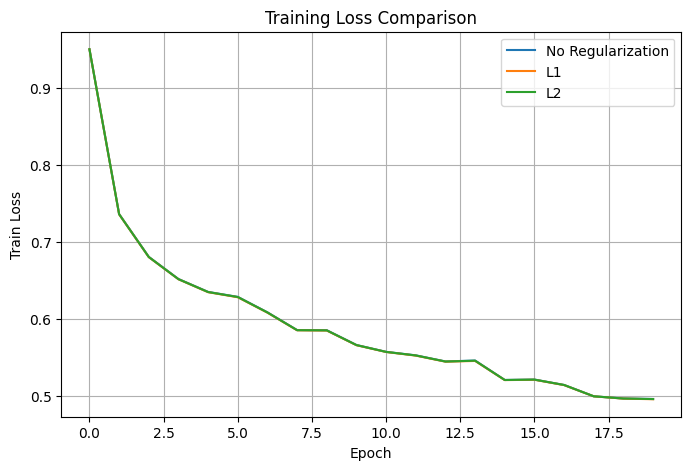

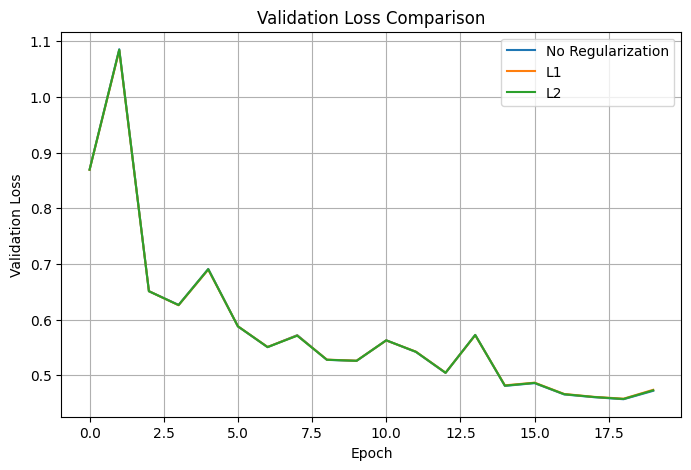


Weight Distribution - No Regularization


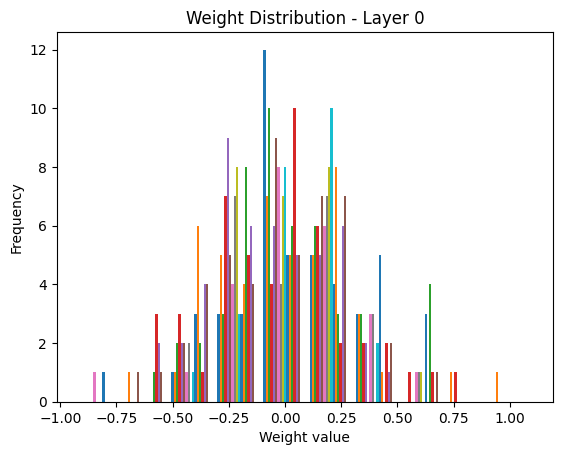

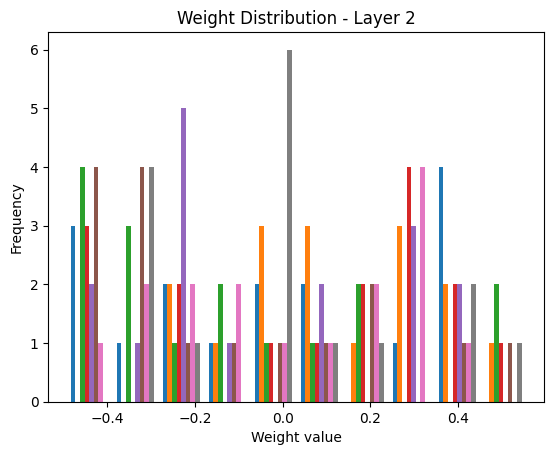

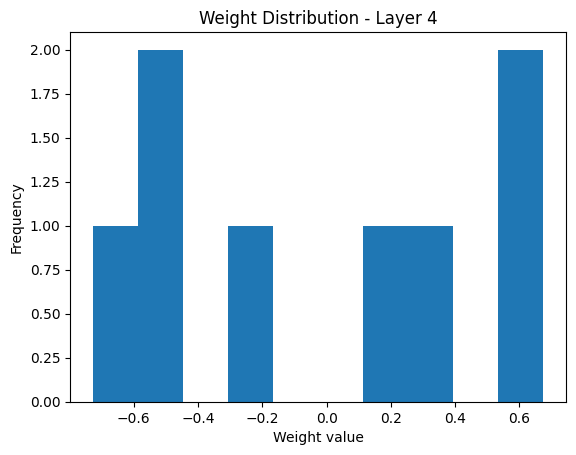

Weight Distribution - L1 Regularization


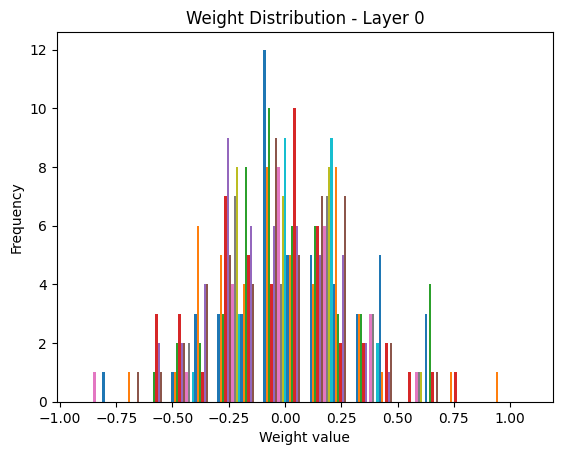

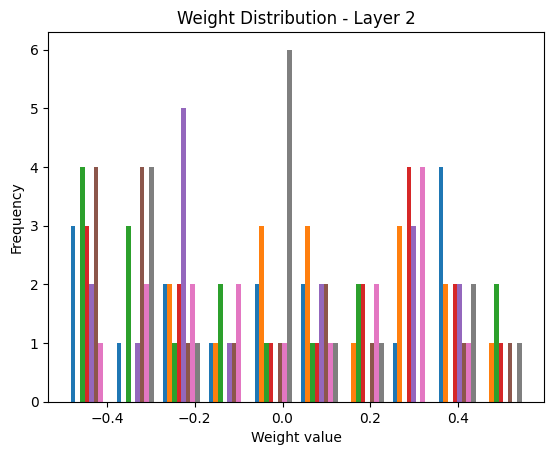

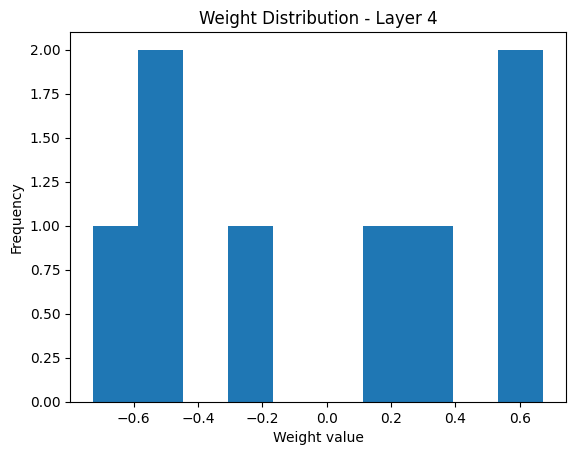

Weight Distribution - L2 Regularization


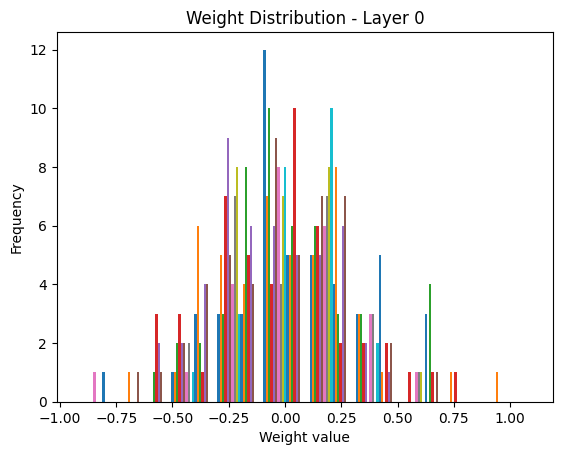

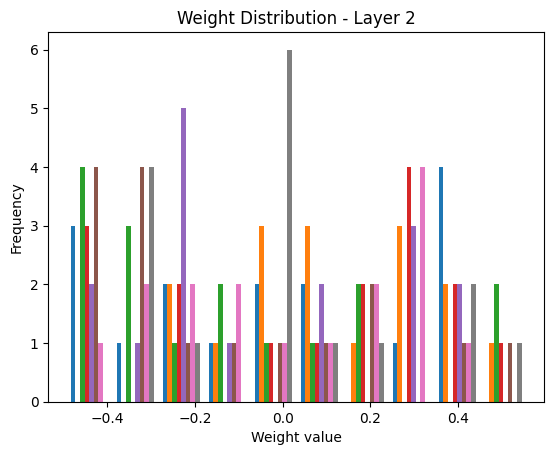

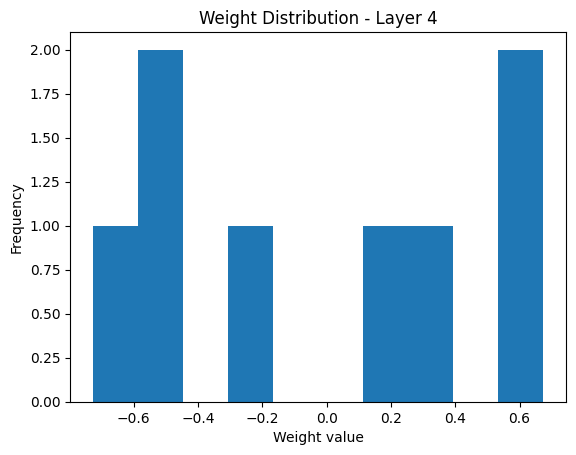


Gradient Distribution - No Regularization


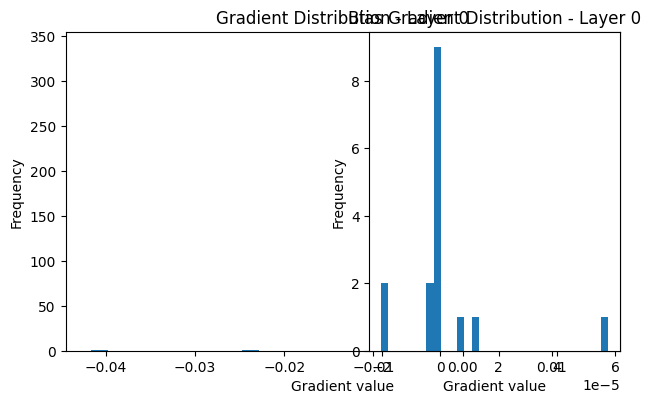

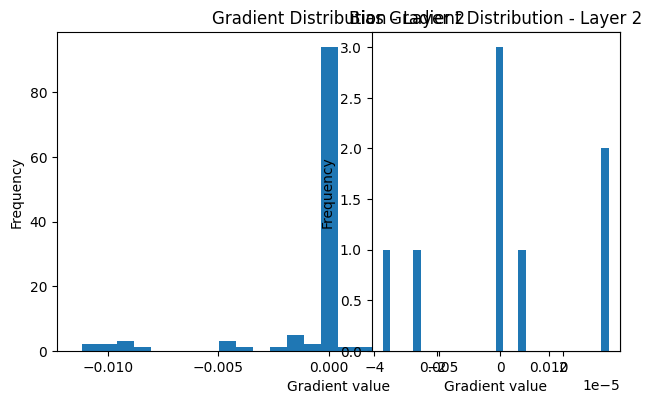

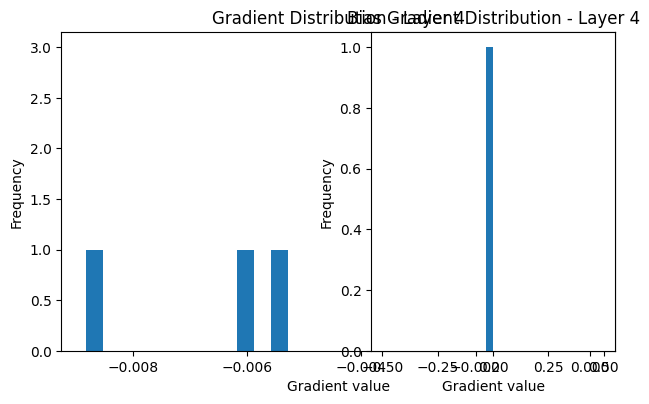

Gradient Distribution - L1 Regularization


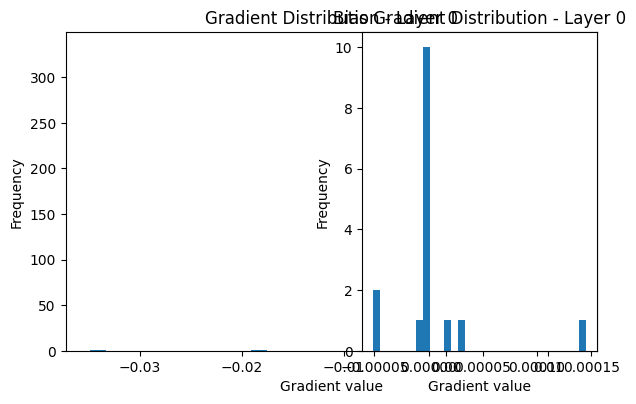

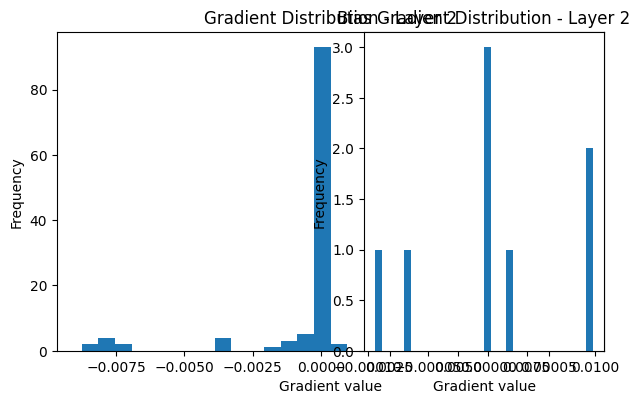

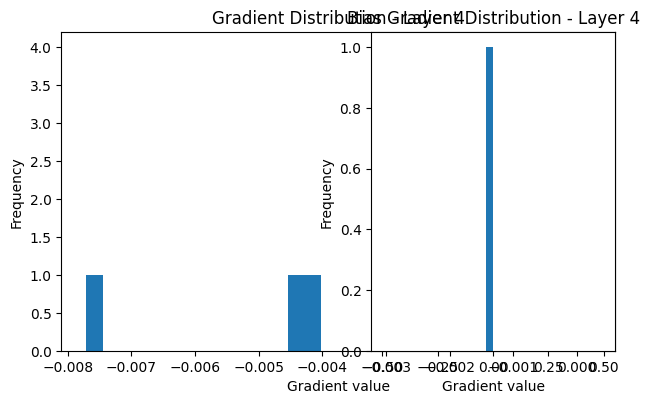

Gradient Distribution - L2 Regularization


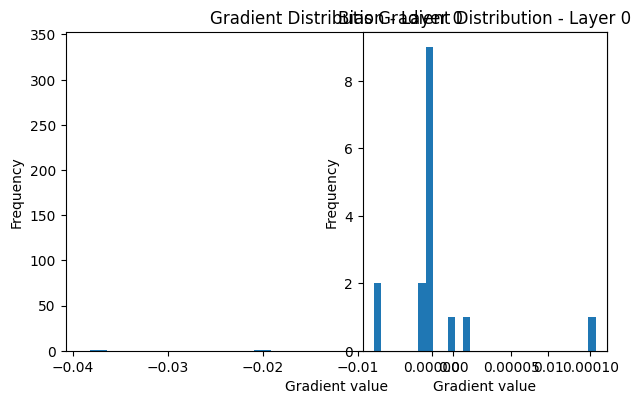

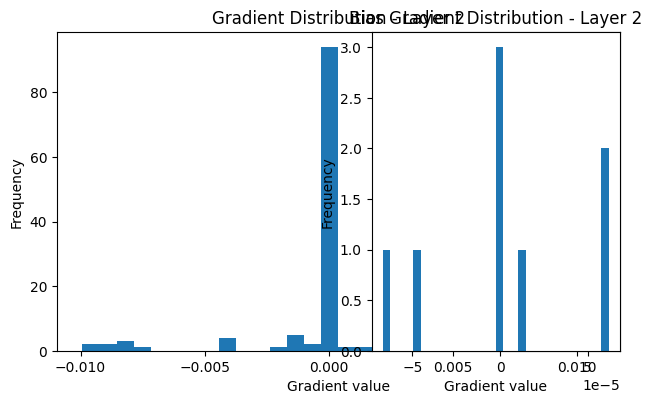

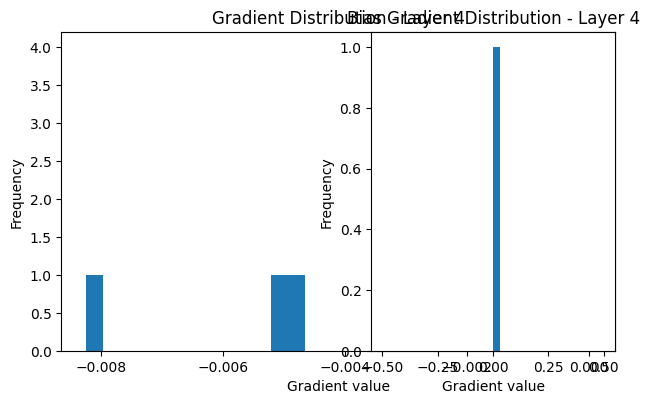

In [99]:
# plot training loss
plt.figure(figsize=(8, 5))
plt.plot(history_none["train_loss"], label="No Regularization")
plt.plot(history_l1["train_loss"], label="L1")
plt.plot(history_l2["train_loss"], label="L2")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

# plot validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_none["val_loss"], label="No Regularization")
plt.plot(history_l1["val_loss"], label="L1")
plt.plot(history_l2["val_loss"], label="L2")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

# plot distribusi weight
print("\nWeight Distribution - No Regularization")
model_none.plot_weight_distribution([0, 2, 4])

print("Weight Distribution - L1 Regularization")
model_l1.plot_weight_distribution([0, 2, 4])

print("Weight Distribution - L2 Regularization")
model_l2.plot_weight_distribution([0, 2, 4])

# plot distribusi gradient
print("\nGradient Distribution - No Regularization")
model_none.plot_gradient_distribution([0, 2, 4])

print("Gradient Distribution - L1 Regularization")
model_l1.plot_gradient_distribution([0, 2, 4])

print("Gradient Distribution - L2 Regularization")
model_l2.plot_gradient_distribution([0, 2, 4])

#### Uji Perbandingan dengan Sklearn

In [100]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [101]:
# init hyperparameter
SEED = 42
EPOCHS = 50
LEARNING_RATE = 0.01
BATCH_SIZE = 32

In [102]:
custom_model = build_regularization_model(l1_lambda=0.0, l2_lambda=0.0, seed=SEED)

history_custom = custom_model.train(
    X_train_np, y_train_np,
    X_val_np, y_val_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=1
)

custom_result = evaluate_binary_model(
    custom_model,
    X_val_np,
    y_val_np,
    model_name="Custom FFNN"
)

# train model sklearn
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    learning_rate="constant",
    learning_rate_init=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    max_iter=EPOCHS,
    shuffle=True,
    random_state=SEED,
    alpha=0.0
)

sklearn_model.fit(X_train_np, y_train_np.reshape(-1))

def evaluate_sklearn_model(model, X_val, y_val, model_name="Sklearn MLP"):
    y_pred = model.predict(X_val)
    y_true = y_val.reshape(-1)

    print()
    print(model_name)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Not Placed", "Placed"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()
    report_df = report_df.drop("accuracy")
    display(report_df)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Accuracy  : {acc:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")
    print()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred
    }

sklearn_result = evaluate_sklearn_model(
    sklearn_model,
    X_val_np,
    y_val_np,
    model_name="Sklearn MLPClassifier"
)

Epoch 1/50, Train Loss=0.950784, Val Loss=0.869382
Epoch 2/50, Train Loss=0.736418, Val Loss=1.085613
Epoch 3/50, Train Loss=0.680811, Val Loss=0.650938
Epoch 4/50, Train Loss=0.652028, Val Loss=0.626295
Epoch 5/50, Train Loss=0.635281, Val Loss=0.690886
Epoch 6/50, Train Loss=0.628828, Val Loss=0.587702
Epoch 7/50, Train Loss=0.608697, Val Loss=0.550419
Epoch 8/50, Train Loss=0.585676, Val Loss=0.571967
Epoch 9/50, Train Loss=0.585440, Val Loss=0.527662
Epoch 10/50, Train Loss=0.566265, Val Loss=0.525791
Epoch 11/50, Train Loss=0.557362, Val Loss=0.562726
Epoch 12/50, Train Loss=0.552809, Val Loss=0.541892
Epoch 13/50, Train Loss=0.544884, Val Loss=0.504189
Epoch 14/50, Train Loss=0.546066, Val Loss=0.572486
Epoch 15/50, Train Loss=0.520792, Val Loss=0.480867
Epoch 16/50, Train Loss=0.521344, Val Loss=0.485824
Epoch 17/50, Train Loss=0.514306, Val Loss=0.465534
Epoch 18/50, Train Loss=0.499560, Val Loss=0.460617
Epoch 19/50, Train Loss=0.496685, Val Loss=0.456933
Epoch 20/50, Train Lo

,precision,recall,f1-score,support
Not Placed,0.910714,0.928479,0.919511,769.0
Placed,0.954770,0.943136,0.948917,1231.0
macro avg,0.932742,0.935807,0.934214,2000.0
weighted avg,0.937830,0.937500,0.937610,2000.0


Accuracy  : 0.9375
Macro F1  : 0.9342


Sklearn MLPClassifier


,precision,recall,f1-score,support
Not Placed,1.0,1.0,1.0,769.0
Placed,1.0,1.0,1.0,1231.0
macro avg,1.0,1.0,1.0,2000.0
weighted avg,1.0,1.0,1.0,2000.0


Accuracy  : 1.0000
Macro F1  : 1.0000



#### Tabel Perbandingan

In [103]:
comparison_sklearn_df = pd.DataFrame([
    {
        "Model": "Custom FFNN",
        "Accuracy": custom_result["accuracy"],
        "Macro F1": custom_result["macro_f1"]
    },
    {
        "Model": "Sklearn MLPClassifier",
        "Accuracy": sklearn_result["accuracy"],
        "Macro F1": sklearn_result["macro_f1"]
    }
])

display(comparison_sklearn_df)

,Model,Accuracy,Macro F1
0,Custom FFNN,0.9375,0.934214
1,Sklearn MLPClassifier,1.0000,1.000000
